# **LAB 5 Linear Regression through Gradient Descent**

# Download and load the Student Performance dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
student_data = pd.read_csv("student-mat.csv", sep=";")
student_data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


#  Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.

In [ ]:
print("Shape:", student_data.shape)

Shape: (395, 33)


In [ ]:
student_data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

 the dataset contains 395 student records with 33 features, including demographic information, family background, study habits, and academic performance

In [ ]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
student_data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
print(student_data.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [ ]:
print("Duplicate Rows:", student_data.duplicated().sum())

Duplicate Rows: 0


zero null values and duplicates found in the dataset

In [ ]:
student_data = pd.get_dummies(student_data, drop_first=True)
X = student_data.drop("G3", axis=1)
y = student_data["G3"]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Categorical features were converted into numerical format using One-Hot Encoding

All input features were standardized using StandardScaler ensuring that every feature has a mean of 0 and a standard deviation of 1

# Select appropriate input features and the target variable.

In [ ]:
X = student_data.drop("G3", axis=1)

y = student_data["G3"]
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (395, 41)
Target Shape: (395,)


# Split the dataset into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
 X_scaled,
 y,
 test_size=0.3,
 random_state=42
)
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 276
Testing Samples: 119


The dataset was divided into 70% training data and 30% testing data

# Implement Linear Regression using the Gradient Descent algorithm.

In [ ]:
import numpy as np
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
 m, n = X.shape
 weights = np.zeros(n)
 bias = 0
 cost_history = []
 for i in range(iterations):

   y_pred = np.dot(X, weights) + bias

   error = y_pred - y

   dw = (1/m) * np.dot(X.T, error)
   db = (1/m) * np.sum(error)

   weights = weights - learning_rate * dw
   bias = bias - learning_rate * db

   cost = (1/(2*m)) * np.sum(error**2)
   cost_history.append(cost)
 return weights, bias, cost_history

In [ ]:
weights, bias, cost_history = gradient_descent(
 X_train,
 y_train,
 learning_rate=0.01,
 iterations=1000
)

In [ ]:
print("Bias:")
print(bias)
print("\nWeights:")
print(weights)

Bias:
10.336184127720365

Weights:
[-1.48059029e-01  5.01225591e-03 -1.83117506e-01  8.85291922e-02
 -1.46003859e-01 -9.64854955e-02  3.26422421e-01 -7.00072222e-02
  1.74145580e-01 -1.77227692e-01  5.26444787e-02  4.09941972e-02
  3.73743742e-01  1.22864258e+00  3.17889562e+00  5.94725255e-02
  1.38481116e-01  7.43964356e-02 -7.24281038e-02 -1.03508690e-01
 -5.76319990e-02 -1.05398084e-02 -2.22990831e-03  1.24507212e-01
  7.24621240e-02  9.31946118e-02 -7.11068921e-02 -1.32854657e-01
 -3.01596778e-01  1.29668459e-01 -1.94269966e-02  1.27427867e-01
 -3.06237811e-02  3.44969633e-01  1.37882693e-01  1.14861074e-01
 -2.30854252e-01 -1.15789908e-01  9.09945651e-02 -2.75737159e-02
 -1.50566427e-01]


# Experiment with different learning rates and observe their effect on model convergence.

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1]

for lr in learning_rates:
    weights, bias, cost_history = gradient_descent(
        X_train,
        y_train,
        learning_rate=lr,
        iterations=1000
    )

    print(f"Learning Rate: {lr}")
    print(f"Final Cost: {cost_history[-1]:.4f}")


Learning Rate: 0.0001
Final Cost: 51.6071
Learning Rate: 0.001
Final Cost: 9.0551
Learning Rate: 0.01
Final Cost: 1.3726
Learning Rate: 0.05
Final Cost: 1.3534
Learning Rate: 0.1
Final Cost: 1.3534


# Plot the loss (cost) versus the number of iterations

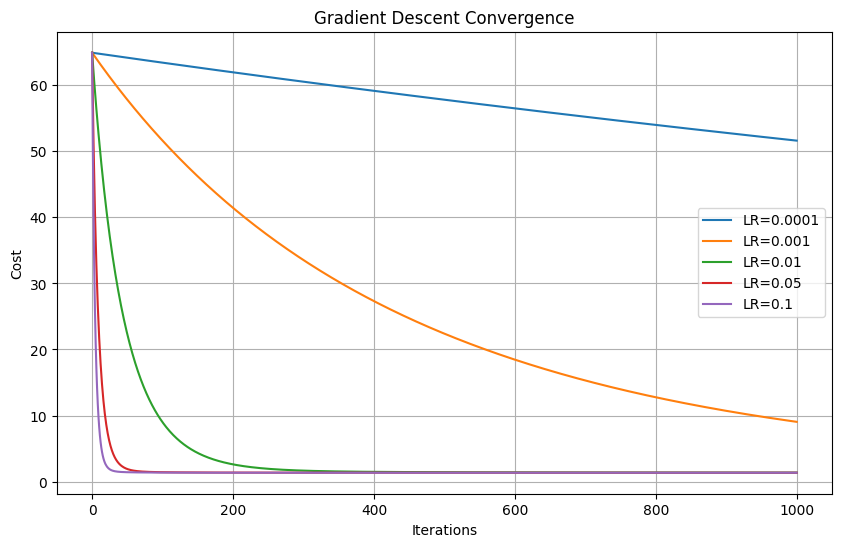

In [ ]:
import matplotlib.pyplot as plt

learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1]

plt.figure(figsize=(10,6))

for lr in learning_rates:
    _, _, cost_history = gradient_descent(
        X_train,
        y_train,
        learning_rate=lr,
        iterations=1000
    )

    plt.plot(cost_history, label=f"LR={lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.show()

# Observations

**LR = 0.0001**

cost decreases very slowly the algorithm has not reached the minimum costv learning rate is too small and results in very slow convergence

**LR = 0.001**
Convergence is much faster than 0.0001 it still requires many iterations to approach the minimum

**LR = 0.01**

the cost decreases rapidly during the initial iterations this is a good learning rate for this dataset

**LR = 0.05**

The cost drops very quickly the algorithm reaches the minimum cost in very few iterations

**LR = 0.1**

This learning rate converges the fastest minimum cost is achieved within only a few iterations no divergence  is observed

# Evaluate the trained model using:

Mean Absolute Error (MAE)

Mean Squared Error (MSE)

Root Mean Squared Error (RMSE)

R² Score


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

weights, bias, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate=0.1,
    iterations=1000
)


y_pred = np.dot(X_test, weights) + bias




In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print("Evaluation Metrics")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Evaluation Metrics
Mean Absolute Error (MAE): 1.525061887153761
Mean Squared Error (MSE): 4.993019390315213
Root Mean Squared Error (RMSE): 2.2345065205353984
R-squared (R²): 0.7728593855649633


# Interpret the results and comment on the convergence behavior and prediction performance of the model

Gradient Descent algorithm successfully learned the relationship between the input features and the final student grade

low MAE and RMSE indicate that the prediction errors are relatively small R² score of 0.773 shows  a significant amount of the variability in student performance

Smaller learning rates require many iterations

Larger learning rates converge much faster

Feature scaling helped Gradient Descent converge efficiently

Learning rates 0.05 and 0.1 achieved the lowest cost and fastest convergence